<a href="https://colab.research.google.com/github/vicayumi/Calculo_Numerico/blob/main/atividade3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Atividade de Calculo Numérico feita por: Victoria Ayumi Kose e Maria Luiza Balbo**

**Enunciado**

Em muitos problemas de engenharia e ciências, é necessário encontrar o valor de uma variável
que torna uma equação igual a zero. Quando não é possível obter esse valor diretamente por
meio de uma fórmula, podem ser usados métodos numéricos iterativos. Esses métodos começam
com uma ou mais aproximações iniciais e, a cada iteração, calculam uma nova aproximação
para a raiz.

Nesta atividade, você implementará em Python os métodos da bisseção, de Newton
e da secante. Em seguida, aplicará os métodos a diferentes funções, analisará os
resultados e produzirá animações gráficas que mostrem o processo de aproximação das
raízes.

Uma raiz de uma função f(x) é um valor r que satisfaz:
f(r) = 0.

Seu objetivo é encontrar aproximações para as raízes das funções propostas e verificar
como o comportamento dos métodos depende da função e das aproximações iniciais
escolhidas.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import math
from IPython.display import display, HTML
from google.colab import files

TOL = 1e-6
MAX_ITER = 100

print("Ambiente configurado!")
print("Tolerância:", TOL)
print("Máximo de iterações:", MAX_ITER)

Ambiente configurado!
Tolerância: 1e-06
Máximo de iterações: 100


**Funções utilizadas:**

Função 1:

$$
f_1(x)=x^2-2
$$

Função 2:

$$
f_2(x)=x^3-x-2
$$

Função 3:

$$
f_3(x)=e^{-x}-x
$$

Função 4:

$$
f_4(x)=x^3-2x+2
$$

Para cada função, foram utilizados os intervalos e as aproximações iniciais:

| Função  | Bisseção | Newton | Secante  |
| ------- | -------- | ------ | -------- |
| \(f_1\) | [1, 2]   | 1,5    | (1, 2)   |
| \(f_2\) | [1, 2]   | 1,5    | (1, 2)   |
| \(f_3\) | [0, 1]   | 0,5    | (0, 1)   |
| \(f_4\) | [-2, -1] | -2     | (-2, -1) |

*Os valores foram mantidos para ter a comparação entre os métodos nas mesmas condições estabelecidas.


In [17]:
# f1(x) = x² - 2
def f1(x):
    return x**2 - 2

def df1(x):
    return 2*x


# f2(x) = x³ - x - 2
def f2(x):
    return x**3 - x - 2

def df2(x):
    return 3*x**2 - 1


# f3(x) = e^(-x) - x
def f3(x):
    return math.exp(-x) - x

def df3(x):
    return -math.exp(-x) - 1


# f4(x) = x³ - 2x + 2
def f4(x):
    return x**3 - 2*x + 2

def df4(x):
    return 3*x**2 - 2


FUNCOES = {
    "f1(x) = x² - 2": (f1, df1, (1, 2), 1.5, (1, 2)),
    "f2(x) = x³ - x - 2": (f2, df2, (1, 2), 1.5, (1, 2)),
    "f3(x) = e⁻ˣ - x": (f3, df3, (0, 1), 0.5, (0, 1)),
    "f4(x) = x³ - 2x + 2": (f4, df4, (-2, -1), -2, (-2, -1))
}

**Parte 1– Implementação dos métodos:**

**Parâmetros e critério de parada:**

Para a execução dos métodos numéricos, foram definidos os seguintes parâmetros:

| Parâmetro                  | Valor                                   |
| -------------------------- | --------------------------------------- |
| Tolerância                 | \(10^{-6}\)                             |
| Número máximo de iterações | 100                                     |
| Critério de convergência   | Resíduo ou diferença entre aproximações |

A convergência é verificada por meio de dois critérios:

**1. Critério baseado na diferença entre aproximações sucessivas:**

$$
|x_{k+1}-x_k|<10^{-6}
$$

**2. Critério baseado no resíduo da função:**

$$
|f(x_{k+1})|<10^{-6}
$$

A execução é encerrada quando pelo menos um dos critérios é satisfeito.

Além disso, o programa verifica situações que podem impedir a continuidade dos cálculos, como intervalo inválido no método da bisseção, derivada próxima de zero no método de Newton e denominador próximo de zero no método da secante.

Caso a convergência não seja alcançada dentro do limite estabelecido, o método informa que o número máximo de iterações foi atingido.

Os valores utilizados permitem padronizar os testes e comparar o comportamento dos métodos nas quatro funções estudadas.


In [18]:
#metodo da bisseção
def bissecao(f, a, b, tol=TOL, max_iter=MAX_ITER):

    fa = f(a)
    fb = f(b)

    historico = []

    if fa == 0:
        return a, 0, [a], True, "Extremo esquerdo é raiz"

    if fb == 0:
        return b, 0, [b], True, "Extremo direito é raiz"

    if fa * fb > 0:
        return None, 0, [], False, "Intervalo inválido"

    anterior = None

    for k in range(1, max_iter + 1):

        meio = (a + b) / 2
        fm = f(meio)

        historico.append(meio)

        if abs(fm) < tol:
            return meio, k, historico, True, "Convergência pelo resíduo"

        if anterior is not None and abs(meio - anterior) < tol:
            return meio, k, historico, True, "Convergência pela diferença"

        if fa * fm < 0:
            b = meio
            fb = fm
        else:
            a = meio
            fa = fm

        anterior = meio

    return historico[-1], max_iter, historico, False, "Máximo de iterações"

In [19]:
#metodo de newton
def newton(f, df, x0, tol=TOL, max_iter=MAX_ITER):

    x = x0
    historico = [x0]

    for k in range(1, max_iter + 1):

        derivada = df(x)

        if abs(derivada) < 1e-14:
            return x, k-1, historico, False, "Derivada próxima de zero"

        xn = x - f(x) / derivada

        historico.append(xn)

        if abs(f(xn)) < tol:
            return xn, k, historico, True, "Convergência pelo resíduo"

        if abs(xn - x) < tol:
            return xn, k, historico, True, "Convergência pela diferença"

        x = xn

    return x, max_iter, historico, False, "Máximo de iterações"

In [20]:
#metodo da secante
def secante(f, x0, x1, tol=TOL, max_iter=MAX_ITER):

    historico = [x0, x1]

    for k in range(1, max_iter + 1):

        f0 = f(x0)
        f1_valor = f(x1)

        denominador = f1_valor - f0

        if abs(denominador) < 1e-14:
            return x1, k-1, historico, False, "Denominador próximo de zero"

        x2 = x1 - f1_valor * (x1 - x0) / denominador

        historico.append(x2)

        if abs(f(x2)) < tol:
            return x2, k, historico, True, "Convergência pelo resíduo"

        if abs(x2 - x1) < tol:
            return x2, k, historico, True, "Convergência pela diferença"

        x0 = x1
        x1 = x2

    return x1, max_iter, historico, False, "Máximo de iterações"

**Parte 2– Aplicação e análise:**

**Resultados obtidos:**

Após a execução dos métodos da bisseção, de Newton-Raphson e da secante nas quatro funções propostas, os resultados foram organizados em uma tabela.

Para cada combinação de função e método, são apresentados os valores iniciais utilizados, a raiz aproximada, o resíduo final e o número de iterações realizadas.

O resíduo corresponde ao módulo do valor da função calculado na aproximação final:

$$|f(x_{\text{aproximado}})|$$

Esse indicador permite avaliar a proximidade da solução numérica em relação à condição desejada (f(x)=0).

A tabela permite comparar a precisão das aproximações e a quantidade de iterações necessárias para cada método.

In [21]:
#executa e gera a tabela
resultados = []

for nome, dados in FUNCOES.items():

    f, df, intervalo, x0, par_secante = dados

    a, b = intervalo

    # Bisseção
    raiz, it, hist, conv, msg = bissecao(f, a, b)

    resultados.append({
        "Função": nome,
        "Método": "Bisseção",
        "Valores iniciais": f"[{a}, {b}]",
        "Raiz aproximada": raiz,
        "|f(x)| final": abs(f(raiz)) if raiz is not None else None,
        "Iterações/resultado": f"{it} / {msg}"
    })

    # Newton
    raiz, it, hist, conv, msg = newton(f, df, x0)

    resultados.append({
        "Função": nome,
        "Método": "Newton",
        "Valores iniciais": str(x0),
        "Raiz aproximada": raiz,
        "|f(x)| final": abs(f(raiz)) if raiz is not None else None,
        "Iterações/resultado": f"{it} / {msg}"
    })

    # Secante
    raiz, it, hist, conv, msg = secante(f, *par_secante)

    resultados.append({
        "Função": nome,
        "Método": "Secante",
        "Valores iniciais": str(par_secante),
        "Raiz aproximada": raiz,
        "|f(x)| final": abs(f(raiz)) if raiz is not None else None,
        "Iterações/resultado": f"{it} / {msg}"
    })

tabela = pd.DataFrame(resultados)

display(tabela.round(10))

,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações/resultado
0,f1(x) = x² - 2,Bisseção,"[1, 2]",1.414214,1.617400e-06,20 / Convergência pela diferença
1,f1(x) = x² - 2,Newton,1.5,1.414214,0.000000e+00,3 / Convergência pelo resíduo
2,f1(x) = x² - 2,Secante,"(1, 2)",1.414214,9.000000e-10,5 / Convergência pelo resíduo
3,f2(x) = x³ - x - 2,Bisseção,"[1, 2]",1.521380,4.265800e-06,20 / Convergência pela diferença
4,f2(x) = x³ - x - 2,Newton,1.5,1.521380,5.894000e-07,2 / Convergência pelo resíduo
5,f2(x) = x³ - x - 2,Secante,"(1, 2)",1.521380,7.000000e-09,6 / Convergência pelo resíduo
6,f3(x) = e⁻ˣ - x,Bisseção,"[0, 1]",0.567143,2.348000e-07,20 / Convergência pelo resíduo
7,f3(x) = e⁻ˣ - x,Newton,0.5,0.567143,1.965000e-07,2 / Convergência pelo resíduo
8,f3(x) = e⁻ˣ - x,Secante,"(0, 1)",0.567143,2.540000e-08,4 / Convergência pelo resíduo
9,f4(x) = x³ - 2x + 2,Bisseção,"[-2, -1]",-1.769292,3.521800e-06,20 / Convergência pela diferença


**Análise dos resultados:**

A partir dos resultados apresentados na tabela, foi possível comparar o comportamento dos três métodos numéricos aplicados às quatro funções.

**Comparação do número de iterações:**

O número de iterações representa a quantidade de etapas necessárias para que cada método satisfaça o critério de parada.

Para as funções analisadas, observou-se que:

* Na função \(f_1(x)=x^2-2\), o método que utilizou menos iterações foi Newton-Raphson, com 3 iterações, seguido pela secante, com 5, e pela bisseção, com 20.
* Na função \(f_2(x)=x^3-x-2\), o método que utilizou menos iterações foi Newton-Raphson, com 2 iterações, seguido pela secante, com 6, e pela bisseção, com 20.
* Na função \(f_3(x)=e^{-x}-x\), o método que utilizou menos iterações foi Newton-Raphson, com 2 iterações, seguido pela secante, com 4, e pela bisseção, com 20.
* Na função \(f_4(x)=x^3-2x+2\), o método que utilizou menos iterações foi Newton-Raphson, com 4 iterações, seguido pela secante, com 6, e pela bisseção, com 20.

**Comparação dos resíduos:**

O resíduo final foi utilizado como indicador da precisão das aproximações encontradas.

Quanto menor o valor de \(|f(x)|\), mais próxima a aproximação está de satisfazer a equação \(f(x)=0\).

Os valores obtidos permitem verificar se os métodos alcançaram a tolerância estabelecida e comparar a precisão das soluções numéricas.

**Influência das aproximações iniciais:**

Os métodos utilizam diferentes informações para calcular as aproximações seguintes.

A bisseção depende de um intervalo que contenha uma mudança de sinal da função. O método de Newton utiliza uma aproximação inicial e o valor da derivada, enquanto a secante utiliza duas aproximações iniciais.

Dessa forma, o comportamento dos métodos depende das características da função e dos valores iniciais utilizados.

**Considerações sobre a convergência:**

A análise dos resultados permite observar que a convergência não depende apenas da quantidade de iterações, mas também do comportamento da função e das condições iniciais.

A comparação entre os métodos evidencia diferenças no processo de aproximação, na quantidade de iterações e nos resíduos finais obtidos.


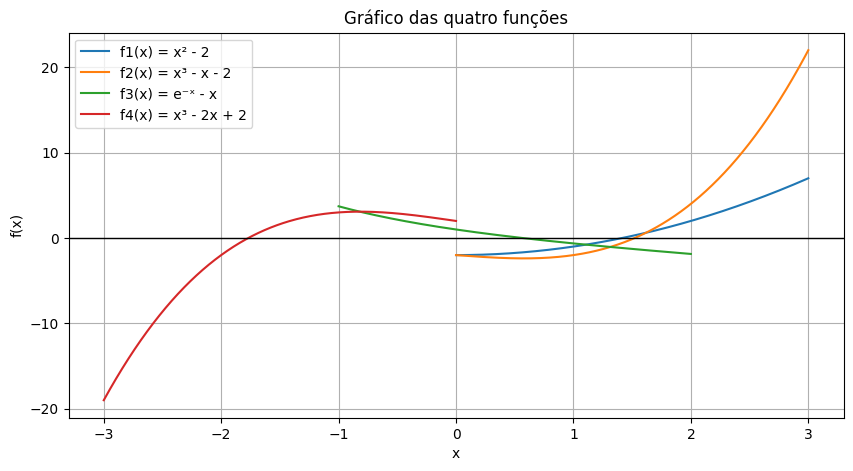

In [22]:
#grafico
plt.figure(figsize=(10, 5))

for nome, (f, df, intervalo, x0, par) in FUNCOES.items():

    x = np.linspace(intervalo[0] - 1, intervalo[1] + 1, 400)

    y = [f(float(valor)) for valor in x]

    plt.plot(x, y, label=nome)

plt.axhline(0, color="black", linewidth=1)

plt.title("Gráfico das quatro funções")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

In [23]:
# animações
def criar_animacao(f, df, metodo, parametros, titulo, arquivo):

    # executa o método uma única vez e utiliza exatamente seu histórico
    if metodo == "Bisseção":
        raiz, iteracoes, historico, convergiu, mensagem = bissecao(
            f, parametros[0], parametros[1]
        )
        a, b = parametros
        fa = f(a)
        estados = []

        for meio in historico:
            estados.append({
                "x": meio,
                "a": a,
                "b": b,
                "indice": len(estados) + 1
            })

            fm = f(meio)
            if fa * fm < 0:
                b = meio
            else:
                a = meio
                fa = fm

    elif metodo == "Newton":
        raiz, iteracoes, historico, convergiu, mensagem = newton(
            f, df, parametros[0]
        )

        estados = []
        for i, x_atual in enumerate(historico):
            estados.append({
                "x": x_atual,
                "anterior": historico[i - 1] if i > 0 else None,
                "indice": i
            })

    elif metodo == "Secante":
        raiz, iteracoes, historico, convergiu, mensagem = secante(
            f, parametros[0], parametros[1]
        )

        estados = []
        for i, x_atual in enumerate(historico):
            estados.append({
                "x": x_atual,
                "anterior1": historico[i - 2] if i >= 2 else None,
                "anterior2": historico[i - 1] if i >= 1 else None,
                "indice": i
            })

    else:
        raise ValueError("Método não reconhecido. Use Bisseção, Newton ou Secante.")

    if not estados:
        raise ValueError("O método não retornou aproximações para animar.")

    valores_x = [estado["x"] for estado in estados]
    valores_x.extend([float(v) for v in parametros])
    xmin, xmax = min(valores_x), max(valores_x)
    amplitude = xmax - xmin
    margem = 0.25 * amplitude if amplitude > 0 else 1.0
    xx = np.linspace(xmin - margem, xmax + margem, 600)
    yy = np.array([f(float(x)) for x in xx])

    fig, ax = plt.subplots(figsize=(8, 5))

    def atualizar(i):
        ax.clear()
        ax.plot(xx, yy, label="f(x)")
        ax.axhline(0, color="black", linewidth=1, label="y = 0")
        ax.grid(True, alpha=0.3)

        estado = estados[i]
        x_atual = estado["x"]

        if metodo == "Bisseção":
            a_atual = estado["a"]
            b_atual = estado["b"]
            ax.axvspan(a_atual, b_atual, color="orange", alpha=0.22,
                       label="Intervalo da iteração")
            ax.axvline(a_atual, color="orange", linestyle="--")
            ax.axvline(b_atual, color="orange", linestyle="--")
            descricao = f"Iteração: {estado['indice']}"

        elif metodo == "Newton":
            anterior = estado["anterior"]
            if anterior is not None:
                tangente_x = np.linspace(xmin - margem, xmax + margem, 200)
                tangente_y = f(anterior) + df(anterior) * (tangente_x - anterior)
                ax.plot(tangente_x, tangente_y, "--", label="Tangente em x anterior")
            descricao = "Iteração: 0 (inicial)" if i == 0 else f"Iteração: {i}"

        else:  # Secante
            x0 = estado["anterior1"]
            x1 = estado["anterior2"]
            if x0 is not None and x1 is not None:
                ax.plot([x0, x1], [f(x0), f(x1)], "--",
                        label="Reta secante da iteração")
            descricao = (
                "Ponto inicial x0" if i == 0
                else "Ponto inicial x1" if i == 1
                else f"Iteração: {i - 1}"
            )

        ax.scatter(x_atual, f(x_atual), color="red", s=60,
                   zorder=5, label="Aproximação atual")
        ax.set_title(
            f"{titulo}\n{descricao} | x = {x_atual:.10f} | "
            f"Resíduo = {abs(f(x_atual)):.2e}"
        )
        ax.set_xlabel("x")
        ax.set_ylabel("f(x)")
        ax.legend(loc="best")

    anim = animation.FuncAnimation(
        fig,
        atualizar,
        frames=len(estados),  # exatamente o número de estados do histórico
        interval=900,
        repeat=True
    )

    anim.save(arquivo, writer=animation.PillowWriter(fps=1))
    plt.close(fig)

    print(f"Animação salva: {arquivo}")
    print(f"Histórico utilizado: {len(historico)} aproximações | "
          f"Iterações retornadas: {iteracoes} | {mensagem}")


In [24]:
#gif bisseção
criar_animacao(
    f1, df1,
    "Bisseção",
    (1, 2),
    "Bisseção — f1(x) = x² - 2",
    "bissecao_f1.gif"
)

Animação salva: bissecao_f1.gif
Histórico utilizado: 20 aproximações | Iterações retornadas: 20 | Convergência pela diferença


In [25]:
#gif newton
criar_animacao(
    f2, df2,
    "Newton",
    (1.5,),
    "Newton — f2(x) = x³ - x - 2",
    "newton_f2.gif"
)

Animação salva: newton_f2.gif
Histórico utilizado: 3 aproximações | Iterações retornadas: 2 | Convergência pelo resíduo


In [26]:
#gif secante
criar_animacao(
    f3, df3,
    "Secante",
    (0, 1),
    "Secante — f3(x) = e⁻ˣ - x",
    "secante_f3.gif"
)

Animação salva: secante_f3.gif
Histórico utilizado: 6 aproximações | Iterações retornadas: 4 | Convergência pelo resíduo


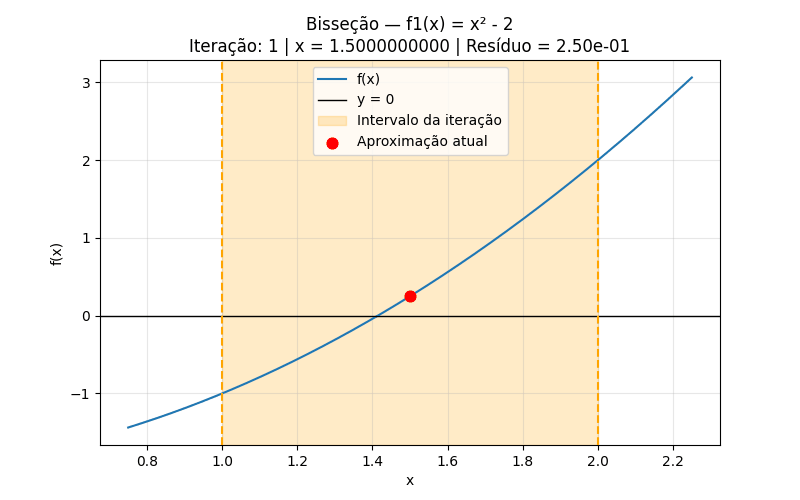

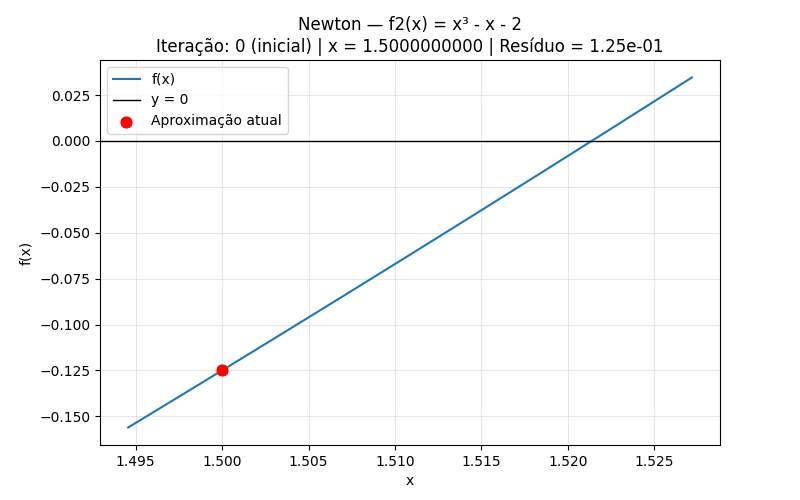

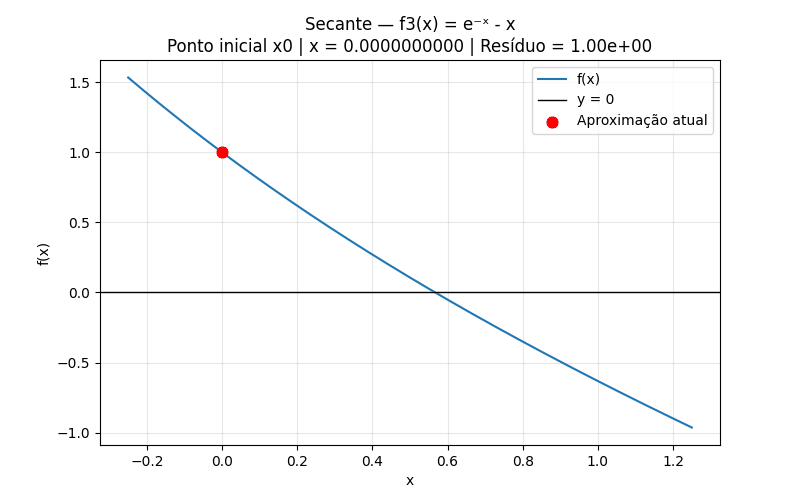

In [27]:
#mostra animação
from IPython.display import Image, display

display(Image(filename="bissecao_f1.gif"))
display(Image(filename="newton_f2.gif"))
display(Image(filename="secante_f3.gif"))

In [28]:
# salva a tabela em CSV
tabela.to_csv("resultados.csv", index=False)

# bauxa os arquivos
files.download("bissecao_f1.gif")
files.download("newton_f2.gif")
files.download("secante_f3.gif")
files.download("resultados.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Conclusão:**

Neste trabalho, foram implementados e aplicados três métodos numéricos para determinação de raízes de funções não lineares: bisseção, Newton-Raphson e secante.

A aplicação dos métodos às quatro funções propostas permitiu observar diferentes processos de aproximação e comparar os resultados obtidos por meio das raízes aproximadas, dos resíduos finais e do número de iterações.

A utilização de critérios de parada e mecanismos de detecção de falhas possibilitou controlar a execução dos algoritmos e identificar situações em que a convergência não é alcançada.

As animações gráficas complementaram a análise, permitindo visualizar a redução dos intervalos, o comportamento das retas tangentes e o processo de construção das retas secantes.

Conclui-se que a implementação computacional dos métodos numéricos permite estudar de maneira prática a determinação aproximada de raízes, além de evidenciar a importância da escolha das aproximações iniciais e da verificação dos critérios de convergência.
